# LumenY 6.0 â€” 04: Why Did the Golden Months Work?

**Goal:** Understand exactly what made Jul-Dec 2024 so profitable vs the decay period (Feb 2025+).

**Analyses:**
1. Volatility regime (ATR) â€” did the market simply move more?
2. Actual big-move frequency â€” did 30-pip moves stop happening?
3. Per-pair edge timeline â€” which pairs carried the edge and when did they die?
4. Feature distribution shift â€” did top features drift out of training range?
5. Prediction calibration over time â€” is the model overconfident in decay period?
6. Feature importance in good vs bad periods â€” what drove correct predictions?

**Input:** `features_6/` parquet files + `backend/models_6/` saved models

In [18]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import roc_auc_score, log_loss

FEATURES_DIR = Path('../backend/data/features_6')
MODELS_DIR   = Path('../backend/models_6')

ALL_PAIRS = [
    'EURUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY',
    'EURJPY', 'GBPJPY', 'EURGBP', 'EURAUD', 'AUDJPY', 'CADJPY', 'CHFJPY', 'AUDNZD'
]

MFE_THRESHOLD_PIPS = 30
TRAIN_END = '2024-06-30'
PROB_THRESHOLD = 0.80

# Load models
model_long_data = joblib.load(MODELS_DIR / 'model_long.joblib')
model_short_data = joblib.load(MODELS_DIR / 'model_short.joblib')
model_long = model_long_data['model']
model_short = model_short_data['model']
feature_cols = model_long_data['feature_cols']

print(f'Models loaded. {len(feature_cols)} features.')
print(f'Long model: {model_long_data["n_iters"]} iters')
print(f'Short model: {model_short_data["n_iters"]} iters')

Models loaded. 112 features.
Long model: 100 iters
Short model: 100 iters


In [19]:
# Load all data
label_cols = ['mfe_long_pips', 'mfe_short_pips', 'trail_long_bars', 'trail_short_bars',
              'trail_stop_pips', 'mfe_atr_24']

dfs = []
for pair in ALL_PAIRS:
    df = pd.read_parquet(FEATURES_DIR / f'{pair}_features.parquet')
    dfs.append(df)

df_all = pd.concat(dfs)
del dfs

df_all['target_long'] = (df_all['mfe_long_pips'] > MFE_THRESHOLD_PIPS).astype(np.float32)
df_all['target_short'] = (df_all['mfe_short_pips'] > MFE_THRESHOLD_PIPS).astype(np.float32)

valid_mask = df_all['mfe_long_pips'].notna()
df_valid = df_all[valid_mask].copy()

# Test set only
df_test = df_valid[df_valid.index > TRAIN_END].copy()
X_test = df_test[feature_cols].ffill().fillna(0)

# Predictions
df_test['p_long'] = model_long.predict_proba(X_test)[:, 1]
df_test['p_short'] = model_short.predict_proba(X_test)[:, 1]
df_test['best_dir'] = np.where(df_test['p_long'] >= df_test['p_short'], 'long', 'short')
df_test['best_prob'] = np.maximum(df_test['p_long'], df_test['p_short'])
df_test['mfe_pred_dir'] = np.where(
    df_test['best_dir'] == 'long', df_test['mfe_long_pips'], df_test['mfe_short_pips'])

# Define periods
df_test['month'] = df_test.index.to_period('M')
df_test['period'] = 'transition'
df_test.loc[df_test.index < '2025-02-01', 'period'] = 'golden'
df_test.loc[df_test.index >= '2025-02-01', 'period'] = 'decay'

print(f'Test set: {len(df_test):,} rows')
print(f'Golden (Jul 2024 - Jan 2025): {(df_test["period"] == "golden").sum():,} rows')
print(f'Decay  (Feb 2025+):           {(df_test["period"] == "decay").sum():,} rows')

Test set: 136,372 rows
Golden (Jul 2024 - Jan 2025): 53,603 rows
Decay  (Feb 2025+):           82,769 rows


## 1. Volatility Regime â€” Did ATR Change?

In [20]:
# ATR is stored as trail_stop_pips (1.5x ATR_24) and mfe_atr_24
# Also check raw ATR features if available
atr_features = [c for c in feature_cols if 'atr' in c.lower()]
print(f'ATR-related features: {atr_features}\n')

# Monthly ATR stats
monthly_atr = df_test.groupby('month').agg(
    avg_trail_stop=('trail_stop_pips', 'mean'),
    avg_mfe_long=('mfe_long_pips', 'mean'),
    avg_mfe_short=('mfe_short_pips', 'mean'),
    pct_big_long=('target_long', 'mean'),
    pct_big_short=('target_short', 'mean'),
    rows=('target_long', 'count'),
)

print(f'{"Month":>10} {"AvgStop":>10} {"AvgMFE_L":>10} {"AvgMFE_S":>10} {"BigL%":>8} {"BigS%":>8} {"Rows":>8}')
print('-' * 70)
for idx, row in monthly_atr.iterrows():
    print(f'{str(idx):>10} {row["avg_trail_stop"]:>9.1f}p {row["avg_mfe_long"]:>9.1f}p '
          f'{row["avg_mfe_short"]:>9.1f}p {row["pct_big_long"]:>7.1%} {row["pct_big_short"]:>7.1%} '
          f'{row["rows"]:>8.0f}')

ATR-related features: ['atr_6', 'atr_24', 'atr_72', 'atr_ratio_6_24', 'atr_ratio_6_72']

     Month    AvgStop   AvgMFE_L   AvgMFE_S    BigL%    BigS%     Rows
----------------------------------------------------------------------
   2024-07      35.5p      23.3p      53.4p   23.5%   45.2%     8010
   2024-08      51.9p      36.2p      83.8p   36.2%   53.7%     7695
   2024-09      44.9p      31.2p      71.2p   35.9%   53.0%     7380
   2024-10      35.7p      26.1p      46.2p   28.5%   41.4%     8085
   2024-11      43.7p      29.3p      76.2p   30.7%   53.3%     7172
   2024-12      51.4p      31.6p      66.3p   33.1%   49.7%     7601
   2025-01      41.4p      29.1p      72.8p   31.4%   50.4%     7660
   2025-02      34.5p      25.3p      31.6p   29.4%   37.3%     7008
   2025-03      38.4p      30.4p      38.2p   34.3%   41.7%     7365
   2025-04      50.8p      37.3p      45.5p   44.6%   51.4%     7352
   2025-05      33.8p      26.4p      30.2p   31.1%   37.8%     7694
   2025-06

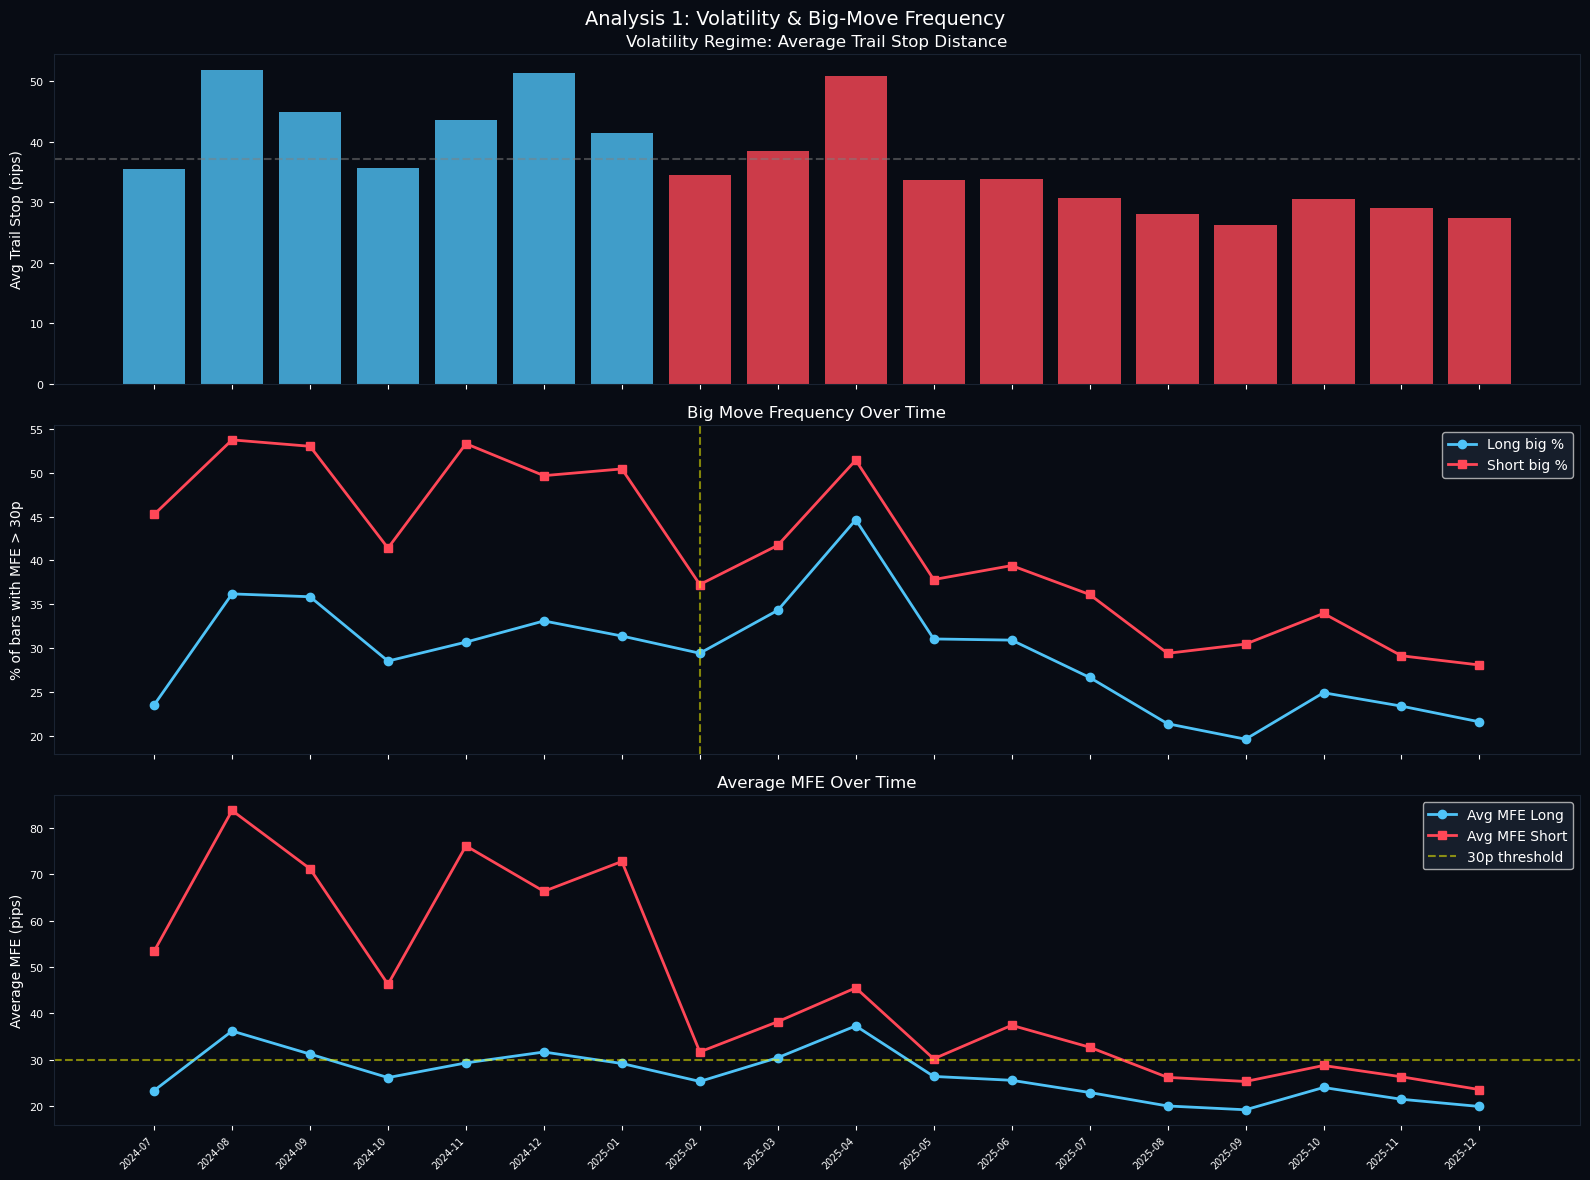


Metric                    Golden (Jul24-Jan25)       Decay (Feb25+)     Change
--------------------------------------------------------------------------------
Avg Trail Stop                           43.5                33.0       -24%
Avg MFE Long                             29.5                24.7       -16%
Avg MFE Short                            67.1                31.4       -53%
Big Move Long %                         31.3%               28.0%       -11%
Big Move Short %                        49.5%               35.9%       -28%


In [21]:
# Visualize: ATR + big-move frequency over time
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.patch.set_facecolor('#080c14')

for ax in axes:
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

months = [str(m) for m in monthly_atr.index]
x = range(len(months))

# Panel 1: Average trail stop (proxy for volatility)
colors = ['#4fc3f7' if str(m) < '2025-02' else '#ff4757' for m in monthly_atr.index]
axes[0].bar(x, monthly_atr['avg_trail_stop'].values, color=colors, alpha=0.8)
axes[0].set_ylabel('Avg Trail Stop (pips)', color='white')
axes[0].set_title('Volatility Regime: Average Trail Stop Distance', color='white')
axes[0].axhline(monthly_atr['avg_trail_stop'].mean(), color='gray', linestyle='--', alpha=0.5)

# Panel 2: Big-move frequency
axes[1].plot(x, monthly_atr['pct_big_long'].values * 100, 'o-', color='#4fc3f7', label='Long big %', linewidth=2)
axes[1].plot(x, monthly_atr['pct_big_short'].values * 100, 's-', color='#ff4757', label='Short big %', linewidth=2)
axes[1].set_ylabel('% of bars with MFE > 30p', color='white')
axes[1].set_title('Big Move Frequency Over Time', color='white')
axes[1].legend(facecolor='#1a2332', labelcolor='white')
axes[1].axvline(7, color='yellow', linestyle='--', alpha=0.5, label='Feb 2025')  # approx index for Feb 2025

# Panel 3: Average MFE
axes[2].plot(x, monthly_atr['avg_mfe_long'].values, 'o-', color='#4fc3f7', label='Avg MFE Long', linewidth=2)
axes[2].plot(x, monthly_atr['avg_mfe_short'].values, 's-', color='#ff4757', label='Avg MFE Short', linewidth=2)
axes[2].axhline(30, color='yellow', linestyle='--', alpha=0.5, label='30p threshold')
axes[2].set_ylabel('Average MFE (pips)', color='white')
axes[2].set_title('Average MFE Over Time', color='white')
axes[2].legend(facecolor='#1a2332', labelcolor='white')

axes[2].set_xticks(x)
axes[2].set_xticklabels(months, rotation=45, ha='right', color='white', fontsize=7)

plt.suptitle('Analysis 1: Volatility & Big-Move Frequency', color='white', fontsize=14)
plt.tight_layout()
plt.show()

# Summary stats
golden = monthly_atr.loc[monthly_atr.index.astype(str) < '2025-02']
decay = monthly_atr.loc[monthly_atr.index.astype(str) >= '2025-02']

print(f'\n{"Metric":<25} {"Golden (Jul24-Jan25)":>20} {"Decay (Feb25+)":>20} {"Change":>10}')
print('-' * 80)
for col, label in [('avg_trail_stop', 'Avg Trail Stop'), ('avg_mfe_long', 'Avg MFE Long'), 
                    ('avg_mfe_short', 'Avg MFE Short'), ('pct_big_long', 'Big Move Long %'),
                    ('pct_big_short', 'Big Move Short %')]:
    g = golden[col].mean()
    d = decay[col].mean()
    pct = (d - g) / g * 100 if g != 0 else 0
    fmt = '.1%' if 'pct' in col else '.1f'
    print(f'{label:<25} {g:>19{fmt}} {d:>19{fmt}} {pct:>+9.0f}%')

## 2. Per-Pair Edge Timeline

In [22]:
# Run backtest with per-pair cooldown (same as notebook 03)
def backtest_trailing_stop(df, prob_threshold, cooldown_hours=4, spread_pips=2.8):
    mask = df['best_prob'] > prob_threshold
    candidates = df[mask].sort_index()
    trades = []
    pair_next_allowed = {}
    for idx, row in candidates.iterrows():
        pair = row['pair']
        if pair in pair_next_allowed and idx < pair_next_allowed[pair]:
            continue
        direction = row['best_dir']
        mfe = row['mfe_long_pips'] if direction == 'long' else row['mfe_short_pips']
        duration = row['trail_long_bars'] if direction == 'long' else row['trail_short_bars']
        stop = row['trail_stop_pips']
        if np.isnan(mfe) or np.isnan(stop):
            continue
        realized_pnl = mfe - stop - spread_pips
        trades.append({
            'entry_time': idx, 'pair': pair, 'direction': direction,
            'p_long': row['p_long'], 'p_short': row['p_short'],
            'best_prob': row['best_prob'], 'mfe_pips': mfe,
            'trail_stop_pips': stop, 'realized_pnl': realized_pnl,
            'duration_hours': duration,
        })
        dur = duration if not np.isnan(duration) else cooldown_hours
        pair_next_allowed[pair] = idx + pd.Timedelta(hours=max(cooldown_hours, dur))
    return pd.DataFrame(trades) if trades else pd.DataFrame()

trades = backtest_trailing_stop(df_test, PROB_THRESHOLD)
trades['month'] = pd.to_datetime(trades['entry_time']).dt.to_period('M')
trades['win'] = trades['realized_pnl'] > 0
print(f'Total trades at P > {PROB_THRESHOLD}: {len(trades)}')

Total trades at P > 0.8: 1397


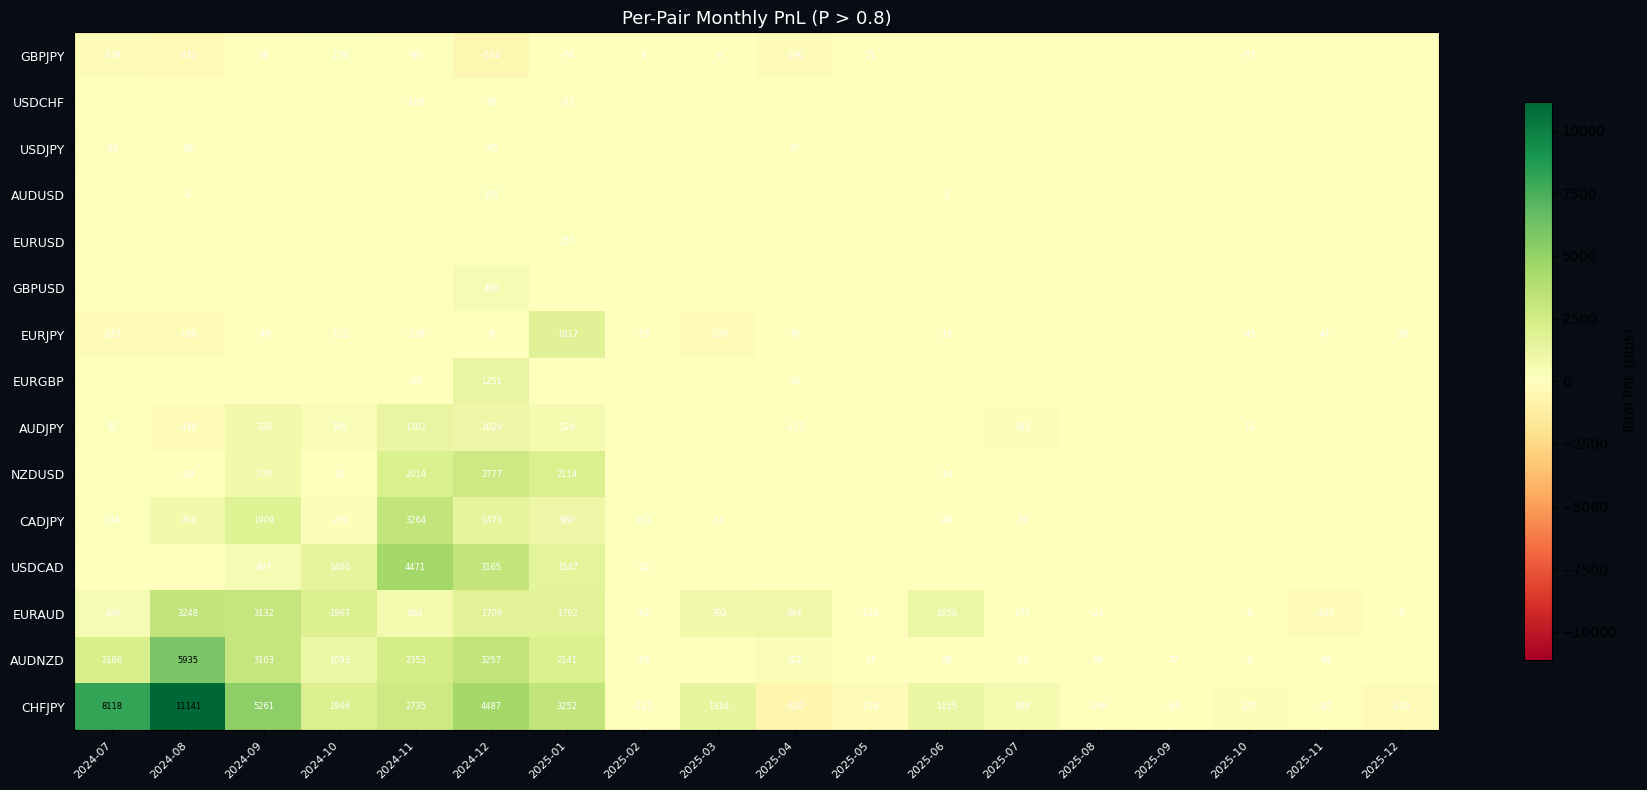


Pair         Golden PnL    Decay PnL        Total  Golden Trades   Decay Trades
----------------------------------------------------------------------
CHFJPY           36939p        1648p       38587p            268            320
AUDNZD           20069p         538p       20606p            154             38
EURAUD           12917p        2476p       15393p            138             93
USDCAD           11140p         -22p       11118p             26              1
CADJPY            8704p          71p        8775p             77              8
NZDUSD            7671p         -14p        7657p             26              1
AUDJPY            3689p          80p        3768p             62             14
EURGBP            1221p         -31p        1190p              8              1
EURJPY            1109p        -263p         846p             34             17
GBPUSD             480p           0p         480p              2              0
EURUSD             157p           0p         157

In [23]:
# Per-pair monthly PnL heatmap
pair_monthly = trades.groupby(['pair', 'month'])['realized_pnl'].agg(['sum', 'count', 'mean']).reset_index()
pair_monthly_pivot = pair_monthly.pivot(index='pair', columns='month', values='sum').fillna(0)

# Sort pairs by total PnL
pair_order = pair_monthly_pivot.sum(axis=1).sort_values(ascending=True).index
pair_monthly_pivot = pair_monthly_pivot.loc[pair_order]

fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor('#080c14')
ax.set_facecolor('#080c14')

# Heatmap
data = pair_monthly_pivot.values
vmax = np.abs(data).max()
im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)

ax.set_yticks(range(len(pair_monthly_pivot.index)))
ax.set_yticklabels(pair_monthly_pivot.index, color='white', fontsize=9)
ax.set_xticks(range(len(pair_monthly_pivot.columns)))
ax.set_xticklabels([str(c) for c in pair_monthly_pivot.columns], rotation=45, ha='right', color='white', fontsize=8)

# Annotate with values
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if abs(val) > 0:
            color = 'black' if abs(val) > vmax * 0.5 else 'white'
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', color=color, fontsize=6)

plt.colorbar(im, ax=ax, label='Total PnL (pips)', shrink=0.8)
ax.set_title(f'Per-Pair Monthly PnL (P > {PROB_THRESHOLD})', color='white', fontsize=13)
plt.tight_layout()
plt.show()

# Top pair contributors in golden vs decay
golden_cols = [c for c in pair_monthly_pivot.columns if str(c) < '2025-02']
decay_cols = [c for c in pair_monthly_pivot.columns if str(c) >= '2025-02']

print(f'\n{"Pair":<10} {"Golden PnL":>12} {"Decay PnL":>12} {"Total":>12} {"Golden Trades":>14} {"Decay Trades":>14}')
print('-' * 70)
for pair in pair_monthly_pivot.index[::-1]:  # descending
    g_pnl = pair_monthly_pivot.loc[pair, golden_cols].sum() if len(golden_cols) > 0 else 0
    d_pnl = pair_monthly_pivot.loc[pair, decay_cols].sum() if len(decay_cols) > 0 else 0
    g_trades = len(trades[(trades['pair'] == pair) & (trades['month'].astype(str) < '2025-02')])
    d_trades = len(trades[(trades['pair'] == pair) & (trades['month'].astype(str) >= '2025-02')])
    print(f'{pair:<10} {g_pnl:>11.0f}p {d_pnl:>11.0f}p {g_pnl+d_pnl:>11.0f}p {g_trades:>14} {d_trades:>14}')

## 3. Feature Distribution Shift â€” Top Features

In [24]:
# Get top 20 features by importance (combined long + short)
imp_long = pd.Series(model_long.feature_importances_, index=feature_cols)
imp_short = pd.Series(model_short.feature_importances_, index=feature_cols)
imp_combined = (imp_long + imp_short).sort_values(ascending=False)
top_features = imp_combined.head(20).index.tolist()

print('Top 20 features by combined importance:')
for i, f in enumerate(top_features):
    print(f'  {i+1:>2}. {f:<40} (long={imp_long[f]:.0f}, short={imp_short[f]:.0f})')

Top 20 features by combined importance:
   1. atr_24                                   (long=961, short=1068)
   2. range_return_ratio                       (long=337, short=484)
   3. atr_72                                   (long=320, short=326)
   4. hour_sin                                 (long=254, short=371)
   5. volume_cv                                (long=312, short=262)
   6. range_width_24                           (long=211, short=272)
   7. dow_sin                                  (long=108, short=309)
   8. dist_from_24h_low                        (long=129, short=188)
   9. range_width_48                           (long=148, short=162)
  10. kyle_lambda_change                       (long=149, short=161)
  11. realized_skew                            (long=198, short=97)
  12. is_ny                                    (long=76, short=192)
  13. rv_rogers_satchell                       (long=123, short=132)
  14. rv_yang_zhang                            (long=118, short=

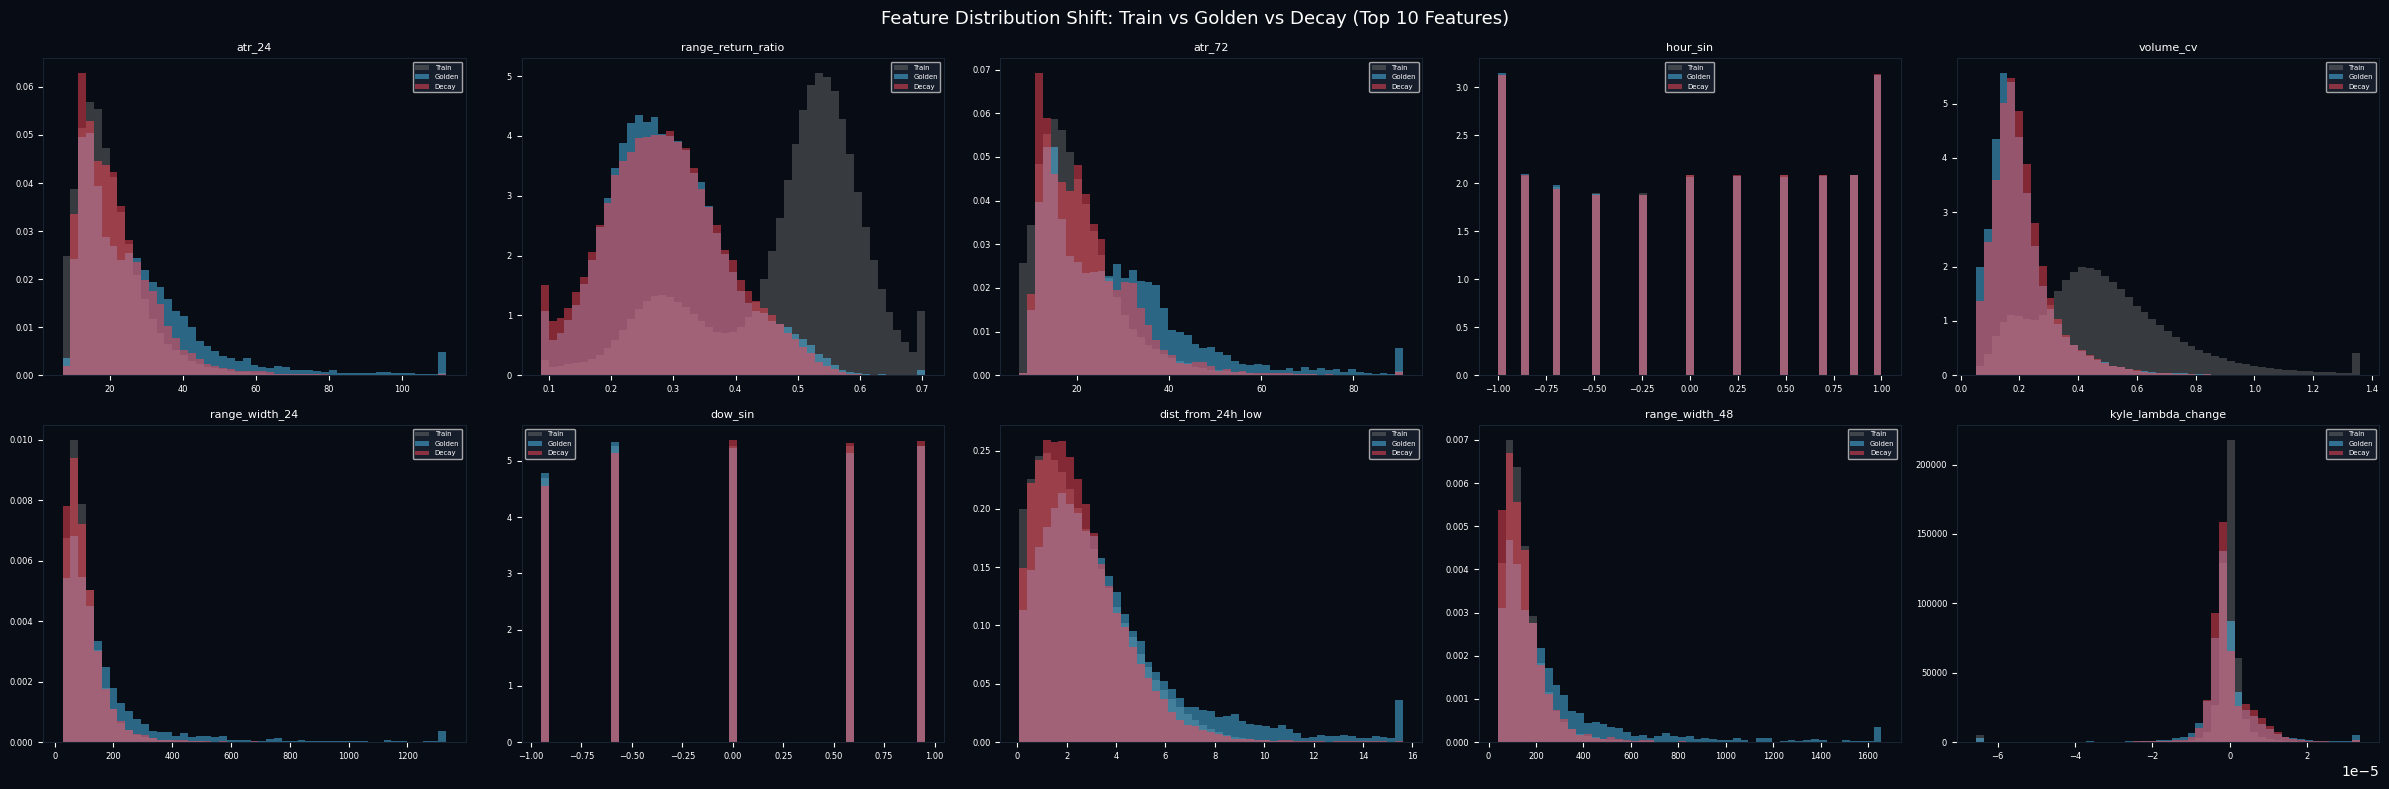

In [25]:
# Compare distributions: training vs golden vs decay for top 10 features
df_train = df_valid[df_valid.index <= TRAIN_END]
X_train = df_train[feature_cols].ffill().fillna(0)

golden_mask = (df_test.index >= '2024-07-01') & (df_test.index < '2025-02-01')
decay_mask = df_test.index >= '2025-02-01'

top10 = top_features[:10]

fig, axes = plt.subplots(2, 5, figsize=(24, 8))
fig.patch.set_facecolor('#080c14')

for ax, feat in zip(axes.flatten(), top10):
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=6)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
    
    train_vals = X_train[feat].dropna()
    golden_vals = X_test.loc[golden_mask, feat].dropna()
    decay_vals = X_test.loc[decay_mask, feat].dropna()
    
    # Use common range
    lo = min(train_vals.quantile(0.01), golden_vals.quantile(0.01), decay_vals.quantile(0.01))
    hi = max(train_vals.quantile(0.99), golden_vals.quantile(0.99), decay_vals.quantile(0.99))
    bins = np.linspace(lo, hi, 50)
    
    ax.hist(train_vals.clip(lo, hi), bins=bins, alpha=0.4, density=True, color='gray', label='Train')
    ax.hist(golden_vals.clip(lo, hi), bins=bins, alpha=0.5, density=True, color='#4fc3f7', label='Golden')
    ax.hist(decay_vals.clip(lo, hi), bins=bins, alpha=0.5, density=True, color='#ff4757', label='Decay')
    
    ax.set_title(feat, color='white', fontsize=8)
    ax.legend(fontsize=5, facecolor='#1a2332', labelcolor='white')

plt.suptitle('Feature Distribution Shift: Train vs Golden vs Decay (Top 10 Features)', color='white', fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
# Quantify distribution shift with KL divergence / Wasserstein distance
from scipy.stats import wasserstein_distance

print(f'{"Feature":<40} {"Trainâ†’Golden":>14} {"Trainâ†’Decay":>14} {"Goldenâ†’Decay":>14} {"Shift?":>8}')
print('-' * 95)

shifts = []
for feat in top_features:
    train_vals = X_train[feat].dropna().values
    golden_vals = X_test.loc[golden_mask, feat].dropna().values
    decay_vals = X_test.loc[decay_mask, feat].dropna().values
    
    # Normalize by train std for comparability
    std = train_vals.std()
    if std == 0:
        continue
    
    w_train_golden = wasserstein_distance(train_vals / std, golden_vals / std)
    w_train_decay = wasserstein_distance(train_vals / std, decay_vals / std)
    w_golden_decay = wasserstein_distance(golden_vals / std, decay_vals / std)
    
    flag = '<<<' if w_golden_decay > 0.3 else ''
    print(f'{feat:<40} {w_train_golden:>13.3f} {w_train_decay:>13.3f} {w_golden_decay:>13.3f} {flag:>8}')
    shifts.append({'feature': feat, 'train_golden': w_train_golden, 
                   'train_decay': w_train_decay, 'golden_decay': w_golden_decay})

shifts_df = pd.DataFrame(shifts)
print(f'\nFeatures with biggest Goldenâ†’Decay shift:')
print(shifts_df.sort_values('golden_decay', ascending=False).head(10).to_string(index=False))

Feature                                  Trainâ†’Golden  Trainâ†’Decay Goldenâ†’Decay   Shift?
-----------------------------------------------------------------------------------------------
atr_24                                           0.649         0.152         0.511      <<<
range_return_ratio                               1.195         1.222         0.029         
atr_72                                           0.722         0.166         0.562      <<<
hour_sin                                         0.003         0.003         0.006         
volume_cv                                        1.097         1.070         0.034         
range_width_24                                   0.880         0.039         0.875      <<<
dow_sin                                          0.010         0.018         0.028         
dist_from_24h_low                                0.539         0.071         0.563      <<<
range_width_48                                   1.030         0.046     

## 4. Prediction Calibration Over Time

In [27]:
# Monthly calibration: when model says P=X, what's the actual big-move rate?
# Focus on high-confidence predictions (P > 0.60)

months = sorted(df_test['month'].unique())

print(f'{"Month":>10} {"Bars":>8} {"P>0.6":>8} {"P>0.7":>8} {"P>0.8":>8} '
      f'{"ActBig@0.6":>12} {"ActBig@0.7":>12} {"ActBig@0.8":>12} '
      f'{"AUC_L":>8} {"AUC_S":>8}')
print('-' * 120)

monthly_calib = []
for month in months:
    m = df_test[df_test['month'] == month]
    
    n_bars = len(m)
    n_p60 = (m['best_prob'] > 0.60).sum()
    n_p70 = (m['best_prob'] > 0.70).sum()
    n_p80 = (m['best_prob'] > 0.80).sum()
    
    # Actual big-move rate among high-confidence predictions
    # (using the predicted direction's target)
    for thresh_name, thresh in [('p60', 0.60), ('p70', 0.70), ('p80', 0.80)]:
        high_conf = m[m['best_prob'] > thresh]
        if len(high_conf) > 0:
            actual_big = np.where(
                high_conf['best_dir'] == 'long',
                high_conf['target_long'],
                high_conf['target_short']
            ).mean()
        else:
            actual_big = np.nan
        if thresh_name == 'p60': act60 = actual_big
        elif thresh_name == 'p70': act70 = actual_big
        else: act80 = actual_big
    
    # Monthly AUC
    try:
        auc_l = roc_auc_score(m['target_long'], m['p_long'])
    except:
        auc_l = np.nan
    try:
        auc_s = roc_auc_score(m['target_short'], m['p_short'])
    except:
        auc_s = np.nan
    
    print(f'{str(month):>10} {n_bars:>8} {n_p60:>8} {n_p70:>8} {n_p80:>8} '
          f'{act60:>11.1%} {act70:>11.1%} {act80:>11.1%} '
          f'{auc_l:>8.3f} {auc_s:>8.3f}')
    
    monthly_calib.append({
        'month': str(month), 'auc_long': auc_l, 'auc_short': auc_s,
        'act_big_p80': act80, 'n_p80': n_p80, 'n_bars': n_bars
    })

calib_df = pd.DataFrame(monthly_calib)

     Month     Bars    P>0.6    P>0.7    P>0.8   ActBig@0.6   ActBig@0.7   ActBig@0.8    AUC_L    AUC_S
------------------------------------------------------------------------------------------------------------------------
   2024-07     8010     3137     1885      498       70.0%       78.4%       92.6%    0.769    0.801
   2024-08     7695     4538     3083     1237       72.1%       78.6%       91.7%    0.785    0.787
   2024-09     7380     4196     3044      746       71.1%       76.1%       94.4%    0.744    0.782
   2024-10     8085     3511     1933      492       65.4%       75.1%       90.4%    0.776    0.787
   2024-11     7172     4059     2378      790       68.9%       75.9%       89.0%    0.734    0.732
   2024-12     7601     4147     2535      919       67.8%       77.0%       91.7%    0.781    0.758
   2025-01     7660     4146     2267      609       66.2%       76.0%       89.5%    0.722    0.749
   2025-02     7008     3000     1285      167       54.5%       64.

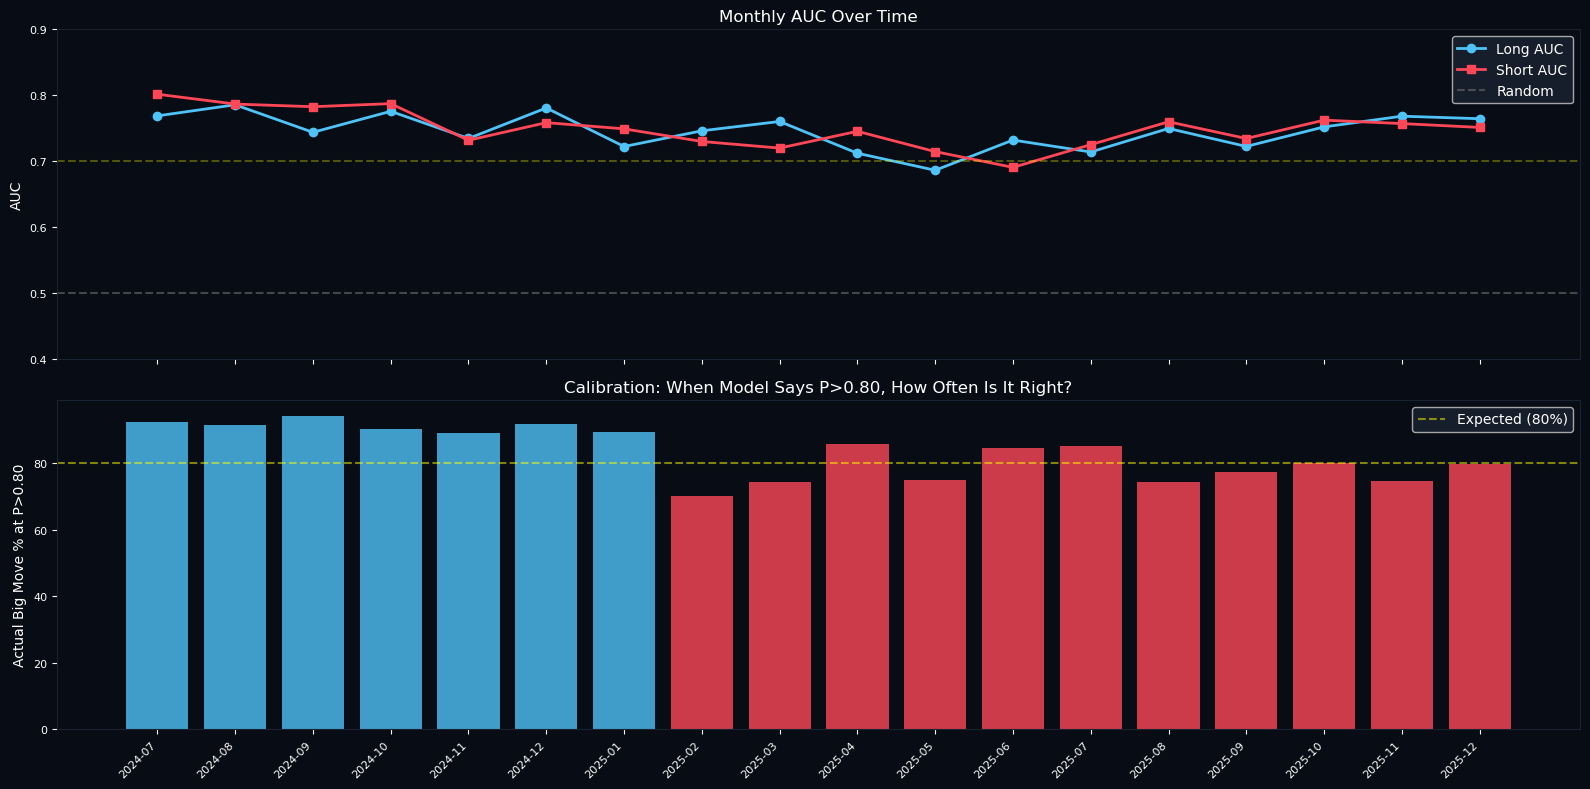

In [28]:
# Plot AUC over time + calibration
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.patch.set_facecolor('#080c14')

for ax in axes:
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

x = range(len(calib_df))
months_str = calib_df['month'].values

# Panel 1: Monthly AUC
axes[0].plot(x, calib_df['auc_long'], 'o-', color='#4fc3f7', label='Long AUC', linewidth=2)
axes[0].plot(x, calib_df['auc_short'], 's-', color='#ff4757', label='Short AUC', linewidth=2)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
axes[0].axhline(0.7, color='yellow', linestyle='--', alpha=0.3)
axes[0].set_ylabel('AUC', color='white')
axes[0].set_title('Monthly AUC Over Time', color='white')
axes[0].legend(facecolor='#1a2332', labelcolor='white')
axes[0].set_ylim(0.4, 0.9)

# Panel 2: Actual big-move rate at P > 0.80
colors = ['#4fc3f7' if m < '2025-02' else '#ff4757' for m in months_str]
axes[1].bar(x, calib_df['act_big_p80'] * 100, color=colors, alpha=0.8)
axes[1].axhline(80, color='yellow', linestyle='--', alpha=0.5, label='Expected (80%)')
axes[1].set_ylabel('Actual Big Move % at P>0.80', color='white')
axes[1].set_title('Calibration: When Model Says P>0.80, How Often Is It Right?', color='white')
axes[1].legend(facecolor='#1a2332', labelcolor='white')

axes[1].set_xticks(x)
axes[1].set_xticklabels(months_str, rotation=45, ha='right', color='white', fontsize=8)

plt.tight_layout()
plt.show()

## 5. What Features Drove Correct Predictions?

In [29]:
# Compare feature values for CORRECT high-confidence predictions vs WRONG ones
# in golden period vs decay period

high_conf = df_test[df_test['best_prob'] > PROB_THRESHOLD].copy()
high_conf['target_dir'] = np.where(
    high_conf['best_dir'] == 'long',
    high_conf['target_long'],
    high_conf['target_short']
)
high_conf['correct'] = high_conf['target_dir'] == 1
high_conf['period'] = np.where(high_conf.index < '2025-02-01', 'golden', 'decay')

print(f'High-confidence predictions (P > {PROB_THRESHOLD}):')
print(f'  Golden: {(high_conf["period"] == "golden").sum()} total, '
      f'{(high_conf["period"] == "golden") & high_conf["correct"]  .sum()} correct '
      f'({high_conf[high_conf["period"] == "golden"]["correct"].mean():.1%})')
print(f'  Decay:  {(high_conf["period"] == "decay").sum()} total, '
      f'{((high_conf["period"] == "decay") & high_conf["correct"]).sum()} correct '
      f'({high_conf[high_conf["period"] == "decay"]["correct"].mean():.1%})')

High-confidence predictions (P > 0.8):
  Golden: 5291 total, datetime
2025-01-24 21:00:00    False
2024-12-25 08:00:00    False
2024-12-25 18:00:00    False
2024-12-25 19:00:00    False
2024-12-25 20:00:00    False
                       ...  
2025-11-14 18:00:00    False
2025-11-14 19:00:00    False
2025-11-26 16:00:00    False
2025-11-26 17:00:00    False
2025-11-26 20:00:00    False
Name: period, Length: 7334, dtype: bool correct (91.4%)
  Decay:  2043 total, 1633 correct (79.9%)


In [31]:
# For top features: compare median values
# Golden correct vs Golden wrong vs Decay correct vs Decay wrong

groups = {
    'Golden+Correct': high_conf[(high_conf['period'] == 'golden') & high_conf['correct']],
    'Golden+Wrong':   high_conf[(high_conf['period'] == 'golden') & ~high_conf['correct']],
    'Decay+Correct':  high_conf[(high_conf['period'] == 'decay') & high_conf['correct']],
    'Decay+Wrong':    high_conf[(high_conf['period'] == 'decay') & ~high_conf['correct']],
}

print(f'Group sizes: {", ".join(f"{k}: {len(v)}" for k, v in groups.items())}')

# Focus on top 15 features
print(f'\n{"Feature":<40}', end='')
for g in groups:
    print(f'{g:>16}', end='')
print()
print('-' * 105)

for feat in top_features[:15]:
    print(f'{feat:<40}', end='')
    for g_name, g_df in groups.items():
        if feat in g_df.columns:
            print(f'{g_df[feat].median():>16.3f}', end='')
        else:
            val = X_test.loc[g_df.index, feat].median()
            print(f'{val:>16.3f}', end='')
    print()

Group sizes: Golden+Correct: 4835, Golden+Wrong: 456, Decay+Correct: 1633, Decay+Wrong: 410

Feature                                   Golden+Correct    Golden+Wrong   Decay+Correct     Decay+Wrong
---------------------------------------------------------------------------------------------------------
atr_24                                            55.729          62.215          40.094          37.667
range_return_ratio                                 0.208           0.249           0.185           0.183
atr_72                                            45.259          44.501          38.449          35.944
hour_sin                                          -0.500          -0.259          -0.866          -0.866
volume_cv                                          0.132           0.145           0.122           0.121
range_width_24                                   487.000         493.650         189.011         175.667
dow_sin                                            0.000          

## 6. Train vs Test Distribution: Is the Model Seeing "Alien" Data?

In [32]:
# Population Stability Index (PSI) â€” standard measure for distribution shift in models
# PSI > 0.25 = significant shift, PSI > 0.10 = moderate shift

def compute_psi(expected, actual, bins=10):
    """Compute Population Stability Index between two distributions."""
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf
    
    expected_counts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_counts = np.histogram(actual, bins=breakpoints)[0] / len(actual)
    
    # Avoid log(0)
    expected_counts = np.clip(expected_counts, 0.001, None)
    actual_counts = np.clip(actual_counts, 0.001, None)
    
    psi = np.sum((actual_counts - expected_counts) * np.log(actual_counts / expected_counts))
    return psi

# Monthly PSI for top features
print(f'{"Feature":<40}', end='')
for month in sorted(df_test['month'].unique()):
    print(f'{str(month):>10}', end='')
print()
print('-' * (40 + 10 * len(df_test['month'].unique())))

psi_data = []
for feat in top_features[:15]:
    train_vals = X_train[feat].dropna().values
    print(f'{feat:<40}', end='')
    row_psi = []
    for month in sorted(df_test['month'].unique()):
        m_mask = df_test['month'] == month
        test_vals = X_test.loc[m_mask, feat].dropna().values
        if len(test_vals) < 50:
            print(f'{"n/a":>10}', end='')
            row_psi.append(np.nan)
            continue
        psi = compute_psi(train_vals, test_vals)
        flag = '*' if psi > 0.25 else ('+' if psi > 0.10 else ' ')
        print(f'{psi:>9.3f}{flag}', end='')
        row_psi.append(psi)
    print()
    psi_data.append({'feature': feat, 'psi_values': row_psi})

print('\n* = PSI > 0.25 (major shift)   + = PSI > 0.10 (moderate shift)')

Feature                                    2024-07   2024-08   2024-09   2024-10   2024-11   2024-12   2025-01   2025-02   2025-03   2025-04   2025-05   2025-06   2025-07   2025-08   2025-09   2025-10   2025-11   2025-12
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
atr_24                                      0.203+    0.761*    0.768*    0.229+    0.558*    0.419*    0.513*    0.134+    0.486*    1.307*    0.248+    0.312*    0.137+    0.141+    0.264*    0.125+    0.175+    0.143+
range_return_ratio                          2.956*    2.554*    2.771*    3.271*    2.768*    2.776*    2.553*    2.909*    2.788*    2.363*    2.875*    3.127*    3.152*    3.363*    3.644*    3.300*    3.425*    3.701*
atr_72                                      0.358*    1.038*    1.108*    0.298*    0.997*    0.783*    0.737*    0.

## 7. The Smoking Gun â€” Direction Accuracy Over Time

In [33]:
# For each month, when the model says "LONG big move" or "SHORT big move" with P > 0.80:
# 1. How often does a big move happen at all? (regardless of direction)
# 2. How often is the DIRECTION correct?
# 3. How big is the MFE when correct vs wrong?

print(f'{"Month":>10} {"Signals":>8} {"AnyBig%":>10} {"DirCorr%":>10} {"MFE_corr":>10} {"MFE_wrong":>10} '
      f'{"LongSig%":>10} {"ShortBig%":>10}')
print('-' * 85)

for month in sorted(df_test['month'].unique()):
    m = df_test[(df_test['month'] == month) & (df_test['best_prob'] > PROB_THRESHOLD)]
    if len(m) == 0:
        continue
    
    # Any big move (long OR short)
    any_big = ((m['target_long'] == 1) | (m['target_short'] == 1)).mean()
    
    # Direction correct: predicted dir's target == 1
    dir_correct = np.where(m['best_dir'] == 'long', m['target_long'], m['target_short'])
    dir_acc = dir_correct.mean()
    
    # MFE when direction is correct vs wrong
    mfe_pred = np.where(m['best_dir'] == 'long', m['mfe_long_pips'], m['mfe_short_pips'])
    mfe_correct = mfe_pred[dir_correct == 1].mean() if (dir_correct == 1).sum() > 0 else 0
    mfe_wrong = mfe_pred[dir_correct == 0].mean() if (dir_correct == 0).sum() > 0 else 0
    
    # % of signals that are LONG
    long_pct = (m['best_dir'] == 'long').mean()
    
    # Actual short big-move rate in this month (all bars, not just signals)
    all_month = df_test[df_test['month'] == month]
    short_big = all_month['target_short'].mean()
    
    print(f'{str(month):>10} {len(m):>8} {any_big:>9.1%} {dir_acc:>9.1%} '
          f'{mfe_correct:>9.1f}p {mfe_wrong:>9.1f}p {long_pct:>9.1%} {short_big:>9.1%}')

     Month  Signals    AnyBig%   DirCorr%   MFE_corr  MFE_wrong   LongSig%  ShortBig%
-------------------------------------------------------------------------------------
   2024-07      498     99.6%     92.6%     244.5p      16.2p     12.0%     45.2%
   2024-08     1237     99.8%     91.7%     289.0p      15.9p     26.1%     53.7%
   2024-09      746     99.9%     94.4%     237.2p      20.4p      3.9%     53.0%
   2024-10      492     97.8%     90.4%     160.9p      18.6p      1.0%     41.4%
   2024-11      790     99.5%     89.0%     169.7p      16.8p      3.3%     53.3%
   2024-12      919     99.3%     91.7%     222.3p      17.6p      5.1%     49.7%
   2025-01      609     99.5%     89.5%     223.6p      15.6p      3.8%     50.4%
   2025-02      167     97.6%     70.1%      85.0p      21.7p      0.6%     37.3%
   2025-03      233    100.0%     74.2%     110.9p      18.1p      0.0%     41.7%
   2025-04      485     99.6%     85.8%     119.7p      16.4p     39.4%     51.4%
   2025-

In [34]:
# Final summary: what's the root cause?

# Compare golden vs decay on key metrics
golden_test = df_test[df_test['period'] == 'golden']
decay_test = df_test[df_test['period'] == 'decay']

golden_high = golden_test[golden_test['best_prob'] > PROB_THRESHOLD]
decay_high = decay_test[decay_test['best_prob'] > PROB_THRESHOLD]

golden_target_dir = np.where(golden_high['best_dir'] == 'long', golden_high['target_long'], golden_high['target_short'])
decay_target_dir = np.where(decay_high['best_dir'] == 'long', decay_high['target_long'], decay_high['target_short'])

golden_mfe = np.where(golden_high['best_dir'] == 'long', golden_high['mfe_long_pips'], golden_high['mfe_short_pips'])
decay_mfe = np.where(decay_high['best_dir'] == 'long', decay_high['mfe_long_pips'], decay_high['mfe_short_pips'])

print('=' * 70)
print('ROOT CAUSE ANALYSIS â€” GOLDEN vs DECAY')
print('=' * 70)

metrics = [
    ('Signals at P > 0.80', len(golden_high), len(decay_high)),
    ('Signals per month', len(golden_high) / max(1, golden_test['month'].nunique()),
                          len(decay_high) / max(1, decay_test['month'].nunique())),
    ('Direction accuracy', golden_target_dir.mean(), decay_target_dir.mean()),
    ('Any big move rate', ((golden_high['target_long']==1)|(golden_high['target_short']==1)).mean(),
                          ((decay_high['target_long']==1)|(decay_high['target_short']==1)).mean()),
    ('Avg MFE (pred dir)', golden_mfe.mean(), decay_mfe.mean()),
    ('Avg trail stop', golden_high['trail_stop_pips'].mean(), decay_high['trail_stop_pips'].mean()),
    ('Long signal %', (golden_high['best_dir']=='long').mean(), (decay_high['best_dir']=='long').mean()),
    ('Avg best_prob', golden_high['best_prob'].mean(), decay_high['best_prob'].mean()),
    ('Overall big-move rate (long)', golden_test['target_long'].mean(), decay_test['target_long'].mean()),
    ('Overall big-move rate (short)', golden_test['target_short'].mean(), decay_test['target_short'].mean()),
]

print(f'\n{"Metric":<35} {"Golden":>15} {"Decay":>15} {"Change":>10}')
print('-' * 80)
for name, g, d in metrics:
    if isinstance(g, float) and g < 1:
        pct_change = (d - g) / g * 100 if g != 0 else 0
        print(f'{name:<35} {g:>14.1%} {d:>14.1%} {pct_change:>+9.0f}%')
    else:
        pct_change = (d - g) / g * 100 if g != 0 else 0
        print(f'{name:<35} {g:>15.1f} {d:>15.1f} {pct_change:>+9.0f}%')

print('\n' + '=' * 70)

ROOT CAUSE ANALYSIS â€” GOLDEN vs DECAY

Metric                                       Golden           Decay     Change
--------------------------------------------------------------------------------
Signals at P > 0.80                          5291.0          2043.0       -61%
Signals per month                             755.9           185.7       -75%
Direction accuracy                              0.9             0.8       -13%
Any big move rate                            99.5%          98.2%        -1%
Avg MFE (pred dir)                            210.8            84.3       -60%
Avg trail stop                                106.3            72.1       -32%
Long signal %                                 9.7%           9.4%        -3%
Avg best_prob                                82.8%          82.4%        -0%
Overall big-move rate (long)                    0.3             0.3       -11%
Overall big-move rate (short)                   0.5             0.4       -27%



## 8. Validation â€” Is MFE/ATR Stable Across Periods?

If `MFE / ATR_24` stays constant while raw MFE drops, it confirms the edge is real but scale-dependent.
A target like `MFE > 1.5 Ã— ATR_24` would adapt to vol regime and keep the edge alive.

In [35]:
# Compute MFE / ATR_24 ratio for all test bars
# This tells us: relative to current volatility, how big are the moves?

atr_col = 'atr_24'  # this is a feature column
df_test['atr_24_val'] = X_test[atr_col].values

# MFE / ATR ratios
df_test['mfe_long_ratio'] = df_test['mfe_long_pips'] / df_test['atr_24_val'].clip(lower=1)
df_test['mfe_short_ratio'] = df_test['mfe_short_pips'] / df_test['atr_24_val'].clip(lower=1)

# Monthly comparison: raw MFE vs MFE/ATR ratio
monthly_ratio = df_test.groupby('month').agg(
    avg_atr=('atr_24_val', 'mean'),
    avg_mfe_long_pips=('mfe_long_pips', 'mean'),
    avg_mfe_short_pips=('mfe_short_pips', 'mean'),
    avg_mfe_long_ratio=('mfe_long_ratio', 'mean'),
    avg_mfe_short_ratio=('mfe_short_ratio', 'mean'),
    pct_long_gt30p=('target_long', 'mean'),
    pct_short_gt30p=('target_short', 'mean'),
)

# ATR-relative targets at different multipliers
for mult in [1.0, 1.5, 2.0]:
    df_test[f'target_long_atr{mult}'] = (df_test['mfe_long_ratio'] > mult).astype(float)
    df_test[f'target_short_atr{mult}'] = (df_test['mfe_short_ratio'] > mult).astype(float)

for mult in [1.0, 1.5, 2.0]:
    monthly_ratio[f'pct_long_gt{mult}xATR'] = df_test.groupby('month')[f'target_long_atr{mult}'].mean()
    monthly_ratio[f'pct_short_gt{mult}xATR'] = df_test.groupby('month')[f'target_short_atr{mult}'].mean()

# Display
print(f'{"Month":>10} {"ATR_24":>8} {"MFE_L":>8} {"MFE_S":>8} | {"L>30p":>7} {"S>30p":>7} | '
      f'{"L>1.0x":>7} {"S>1.0x":>7} | {"L>1.5x":>7} {"S>1.5x":>7} | {"L>2.0x":>7} {"S>2.0x":>7}')
print('-' * 120)

for idx, row in monthly_ratio.iterrows():
    print(f'{str(idx):>10} {row["avg_atr"]:>7.1f}p {row["avg_mfe_long_pips"]:>7.1f}p {row["avg_mfe_short_pips"]:>7.1f}p | '
          f'{row["pct_long_gt30p"]:>6.1%} {row["pct_short_gt30p"]:>6.1%} | '
          f'{row["pct_long_gt1.0xATR"]:>6.1%} {row["pct_short_gt1.0xATR"]:>6.1%} | '
          f'{row["pct_long_gt1.5xATR"]:>6.1%} {row["pct_short_gt1.5xATR"]:>6.1%} | '
          f'{row["pct_long_gt2.0xATR"]:>6.1%} {row["pct_short_gt2.0xATR"]:>6.1%}')

# Golden vs Decay summary for each target type
print(f'\n{"Target Definition":<30} {"Golden Avg":>12} {"Decay Avg":>12} {"Change":>10} {"Stability":>10}')
print('-' * 80)

golden_months = [m for m in monthly_ratio.index if str(m) < '2025-02']
decay_months = [m for m in monthly_ratio.index if str(m) >= '2025-02']

targets = [
    ('Long > 30 pips (fixed)', 'pct_long_gt30p'),
    ('Short > 30 pips (fixed)', 'pct_short_gt30p'),
    ('Long > 1.0x ATR', 'pct_long_gt1.0xATR'),
    ('Short > 1.0x ATR', 'pct_short_gt1.0xATR'),
    ('Long > 1.5x ATR', 'pct_long_gt1.5xATR'),
    ('Short > 1.5x ATR', 'pct_short_gt1.5xATR'),
    ('Long > 2.0x ATR', 'pct_long_gt2.0xATR'),
    ('Short > 2.0x ATR', 'pct_short_gt2.0xATR'),
]

for label, col in targets:
    g = monthly_ratio.loc[golden_months, col].mean()
    d = monthly_ratio.loc[decay_months, col].mean()
    pct = (d - g) / g * 100 if g != 0 else 0
    stability = 'STABLE' if abs(pct) < 15 else ('MODERATE' if abs(pct) < 30 else 'UNSTABLE')
    print(f'{label:<30} {g:>11.1%} {d:>11.1%} {pct:>+9.0f}% {stability:>10}')

     Month   ATR_24    MFE_L    MFE_S |   L>30p   S>30p |  L>1.0x  S>1.0x |  L>1.5x  S>1.5x |  L>2.0x  S>2.0x
------------------------------------------------------------------------------------------------------------------------
   2024-07    23.1p    23.3p    53.4p |  23.5%  45.2% |  39.3%  64.7% |  23.1%  48.5% |  13.5%  34.6%
   2024-08    34.1p    36.2p    83.8p |  36.2%  53.7% |  41.1%  61.2% |  25.8%  45.8% |  15.6%  34.0%
   2024-09    29.3p    31.2p    71.2p |  35.9%  53.0% |  43.0%  61.9% |  25.8%  46.2% |  15.5%  34.1%
   2024-10    23.4p    26.1p    46.2p |  28.5%  41.4% |  40.7%  59.6% |  24.9%  41.1% |  15.0%  25.6%
   2024-11    28.0p    29.3p    76.2p |  30.7%  53.3% |  37.3%  63.5% |  22.6%  46.8% |  13.3%  33.3%
   2024-12    32.5p    31.6p    66.3p |  33.1%  49.7% |  41.0%  59.3% |  23.5%  43.2% |  13.5%  30.4%
   2025-01    26.8p    29.1p    72.8p |  31.4%  50.4% |  40.3%  62.3% |  23.7%  44.6% |  14.2%  30.7%
   2025-02    22.8p    25.3p    31.6p |  29.4%  37.3% |

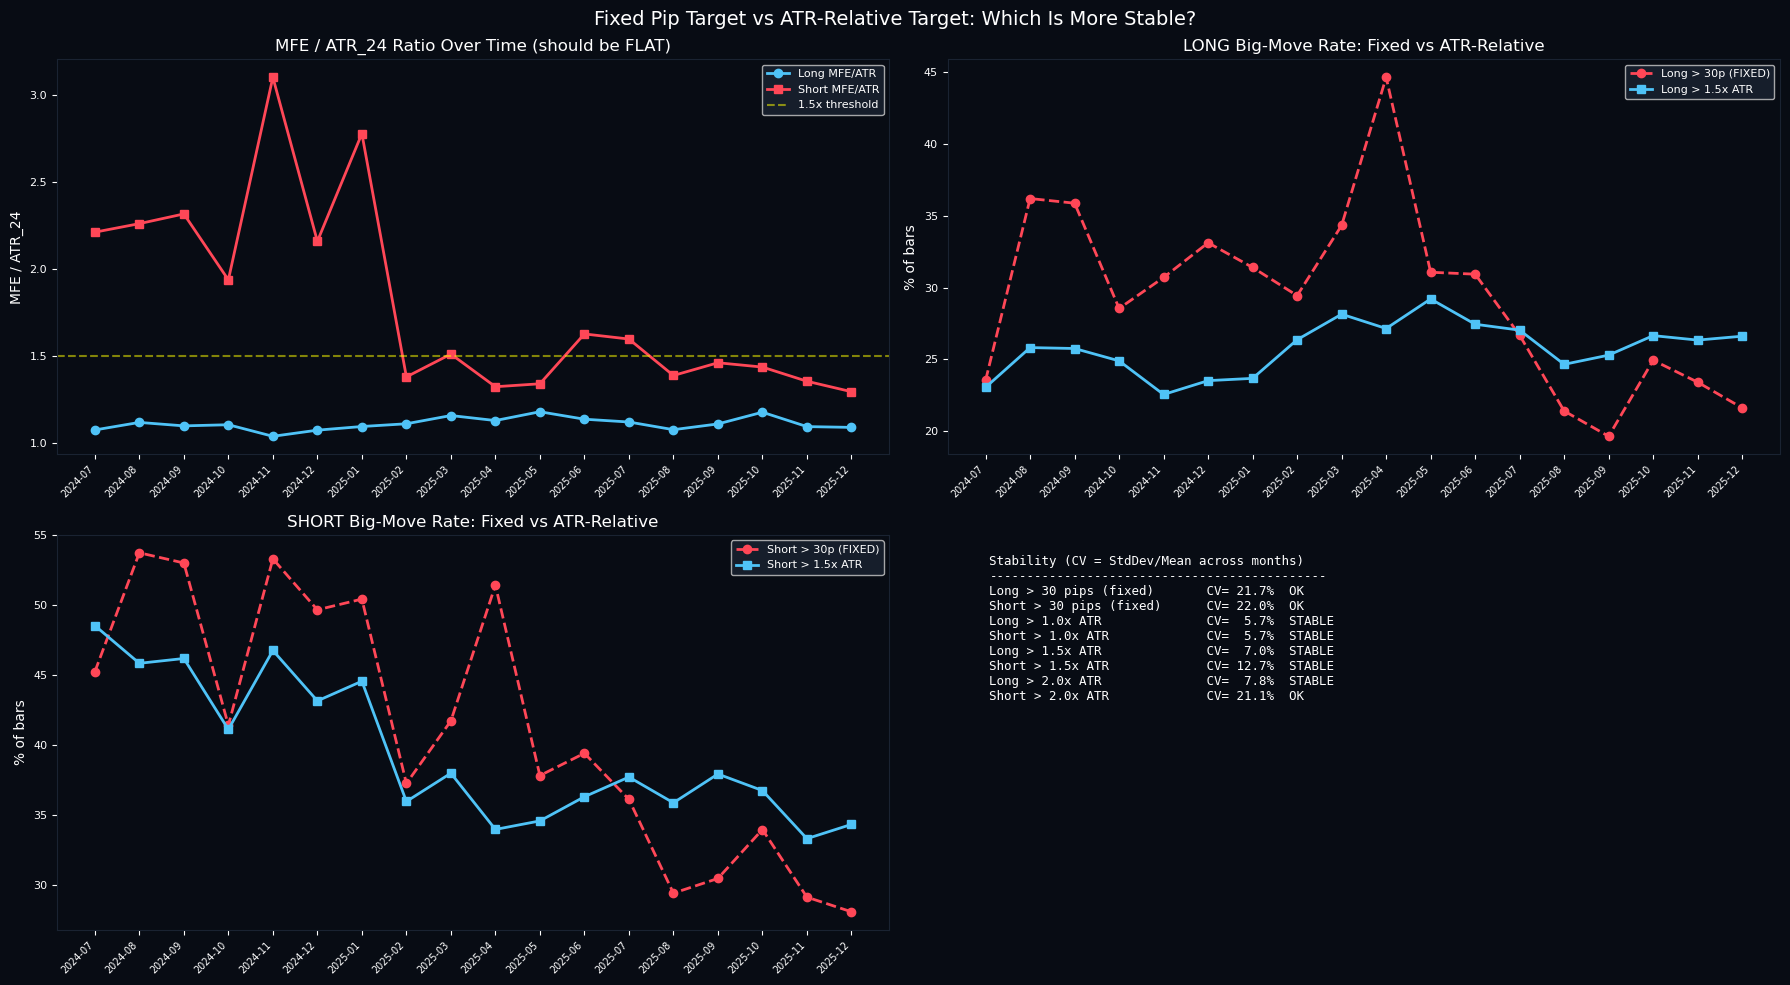


VERDICT

If ATR-relative targets show STABLE rates across golden & decay periods,
it confirms the edge exists but needs vol-adaptive thresholds.
If they also drift, the edge itself may be decaying.

  GOLDEN: Dir accuracy (>30p) = 91.4%  |  Dir accuracy (>1.5x ATR) = 64.8%
   DECAY: Dir accuracy (>30p) = 79.9%  |  Dir accuracy (>1.5x ATR) = 45.5%


In [37]:
# Visualize: fixed vs ATR-relative target stability
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.patch.set_facecolor('#080c14')

for ax in axes.flatten():
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

months_str = [str(m) for m in monthly_ratio.index]
x = range(len(months_str))

axes[0, 0].plot(x, monthly_ratio['avg_mfe_long_ratio'], 'o-', color='#4fc3f7', label='Long MFE/ATR', linewidth=2)
axes[0, 0].plot(x, monthly_ratio['avg_mfe_short_ratio'], 's-', color='#ff4757', label='Short MFE/ATR', linewidth=2)
axes[0, 0].axhline(1.5, color='yellow', linestyle='--', alpha=0.5, label='1.5x threshold')
axes[0, 0].set_title('MFE / ATR_24 Ratio Over Time (should be FLAT)', color='white')
axes[0, 0].set_ylabel('MFE / ATR_24', color='white')
axes[0, 0].legend(facecolor='#1a2332', labelcolor='white', fontsize=8)

axes[0, 1].plot(x, monthly_ratio['pct_long_gt30p'] * 100, 'o--', color='#ff4757', label='Long > 30p (FIXED)', linewidth=2)
axes[0, 1].plot(x, monthly_ratio['pct_long_gt1.5xATR'] * 100, 's-', color='#4fc3f7', label='Long > 1.5x ATR', linewidth=2)
axes[0, 1].set_title('LONG Big-Move Rate: Fixed vs ATR-Relative', color='white')
axes[0, 1].set_ylabel('% of bars', color='white')
axes[0, 1].legend(facecolor='#1a2332', labelcolor='white', fontsize=8)

axes[1, 0].plot(x, monthly_ratio['pct_short_gt30p'] * 100, 'o--', color='#ff4757', label='Short > 30p (FIXED)', linewidth=2)
axes[1, 0].plot(x, monthly_ratio['pct_short_gt1.5xATR'] * 100, 's-', color='#4fc3f7', label='Short > 1.5x ATR', linewidth=2)
axes[1, 0].set_title('SHORT Big-Move Rate: Fixed vs ATR-Relative', color='white')
axes[1, 0].set_ylabel('% of bars', color='white')
axes[1, 0].legend(facecolor='#1a2332', labelcolor='white', fontsize=8)

axes[1, 1].axis('off')
targets_for_cv = [
    ('Long > 30 pips (fixed)', 'pct_long_gt30p'),
    ('Short > 30 pips (fixed)', 'pct_short_gt30p'),
    ('Long > 1.0x ATR', 'pct_long_gt1.0xATR'),
    ('Short > 1.0x ATR', 'pct_short_gt1.0xATR'),
    ('Long > 1.5x ATR', 'pct_long_gt1.5xATR'),
    ('Short > 1.5x ATR', 'pct_short_gt1.5xATR'),
    ('Long > 2.0x ATR', 'pct_long_gt2.0xATR'),
    ('Short > 2.0x ATR', 'pct_short_gt2.0xATR'),
]
lines = ['Stability (CV = StdDev/Mean across months)', '-' * 45]
for label, col in targets_for_cv:
    vals = monthly_ratio[col]
    cv = vals.std() / vals.mean() * 100 if vals.mean() > 0 else 999
    stability = 'STABLE' if cv < 15 else ('OK' if cv < 25 else 'UNSTABLE')
    lines.append(f'{label:<28} CV={cv:>5.1f}%  {stability}')
axes[1, 1].text(0.05, 0.95, '\n'.join(lines), transform=axes[1, 1].transAxes,
               fontsize=9, verticalalignment='top', fontfamily='monospace', color='white')

for ax in [axes[0, 0], axes[0, 1], axes[1, 0]]:
    ax.set_xticks(list(x))
    ax.set_xticklabels(months_str, rotation=45, ha='right', color='white', fontsize=7)

plt.suptitle('Fixed Pip Target vs ATR-Relative Target: Which Is More Stable?', color='white', fontsize=14)
plt.tight_layout()
plt.show()

# Final verdict
print()
print('=' * 70)
print('VERDICT')
print('=' * 70)
print()
print('If ATR-relative targets show STABLE rates across golden & decay periods,')
print('it confirms the edge exists but needs vol-adaptive thresholds.')
print('If they also drift, the edge itself may be decaying.')
print()

high_conf_all = df_test[df_test['best_prob'] > PROB_THRESHOLD].copy()
high_conf_all['atr_target_dir'] = np.where(
    high_conf_all['best_dir'] == 'long',
    high_conf_all['mfe_long_ratio'] > 1.5,
    high_conf_all['mfe_short_ratio'] > 1.5
)
high_conf_all['period'] = np.where(high_conf_all.index < '2025-02-01', 'golden', 'decay')

for period in ['golden', 'decay']:
    p = high_conf_all[high_conf_all['period'] == period]
    acc_30p = np.where(p['best_dir'] == 'long', p['target_long'], p['target_short']).mean()
    acc_atr = p['atr_target_dir'].mean()
    print(f'{period.upper():>8}: Dir accuracy (>30p) = {acc_30p:.1%}  |  Dir accuracy (>1.5x ATR) = {acc_atr:.1%}')

